In [1]:
# Reload saved weights for A1, A2, A3 results (already saved)
# We just need to record we have these results and move to A4

import tensorflow as tf
import numpy as np
import os
from tensorflow.keras.applications import EfficientNetB5, ResNet50, DenseNet121
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)

TRAIN_DIR = 'D:/brain_tumor_project/dataset/Training'
TEST_DIR  = 'D:/brain_tumor_project/dataset/Testing'
MODEL_DIR = 'D:/brain_tumor_project/models'
CLASSES   = ['glioma', 'meningioma', 'notumor', 'pituitary']

train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=20, width_shift_range=0.1,
    height_shift_range=0.1, shear_range=0.1, zoom_range=0.1,
    horizontal_flip=True, validation_split=0.2
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(128,128), batch_size=16,
    class_mode='categorical', subset='training', seed=42
)
val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(128,128), batch_size=16,
    class_mode='categorical', subset='validation', seed=42
)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=(128,128), batch_size=16,
    class_mode='categorical', shuffle=False
)

def se_block(x, ratio=8):
    channels = x.shape[-1]
    se = layers.GlobalAveragePooling2D(keepdims=True)(x)
    se = layers.Dense(channels // ratio, activation='relu', use_bias=False)(se)
    se = layers.Dense(channels, activation='sigmoid', use_bias=False)(se)
    return layers.Multiply()([x, se])

def cbam_block(x, ratio=8):
    channels = x.shape[-1]
    avg_pool = layers.GlobalAveragePooling2D(keepdims=True)(x)
    max_pool = layers.GlobalMaxPooling2D(keepdims=True)(x)
    shared1 = layers.Dense(channels // ratio, activation='relu', use_bias=False)
    shared2 = layers.Dense(channels, use_bias=False)
    avg_out = shared2(shared1(avg_pool))
    max_out = shared2(shared1(max_pool))
    channel_att = layers.Activation('sigmoid')(layers.Add()([avg_out, max_out]))
    x = layers.Multiply()([x, channel_att])
    avg_sp = tf.reduce_mean(x, axis=-1, keepdims=True)
    max_sp = tf.reduce_max(x, axis=-1, keepdims=True)
    spatial = layers.Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(
        layers.Concatenate(axis=-1)([avg_sp, max_sp]))
    return layers.Multiply()([x, spatial])

def hybrid_block(x):
    return cbam_block(se_block(x))

def build_model(base_fn, attention_fn=None, num_classes=4):
    base = base_fn(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
    base.trainable = False
    x = base.output
    if attention_fn:
        x = attention_fn(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    return Model(inputs=base.input,
                 outputs=layers.Dense(num_classes, activation='softmax')(x))

def train_model(model, model_name, epochs=25):
    for layer in model.layers:
        layer.trainable = True
    freeze_until = int(len(model.layers) * 0.5)
    for layer in model.layers[:freeze_until]:
        layer.trainable = False
    print(f"Trainable layers: {sum([1 for l in model.layers if l.trainable])}")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    train_gen.reset()
    val_gen.reset()
    save_path = f'{MODEL_DIR}/{model_name}_best.h5'

    class SaveBestModel(tf.keras.callbacks.Callback):
        def __init__(self):
            self.best = 0
        def on_epoch_end(self, epoch, logs=None):
            val_acc = logs.get('val_accuracy', 0)
            if val_acc > self.best:
                self.best = val_acc
                self.model.save_weights(save_path)
                print(f'\nSaved best model with val_accuracy: {val_acc:.4f}')

    history = model.fit(
        train_gen, epochs=epochs, validation_data=val_gen,
        callbacks=[
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
            EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1),
            SaveBestModel()
        ], verbose=1
    )
    return history

def evaluate_model(model, model_name):
    test_gen.reset()
    results = model.evaluate(test_gen, verbose=0)
    print(f"\n{model_name} — Test Accuracy: {results[1]*100:.2f}%")
    test_gen.reset()
    y_pred = np.argmax(model.predict(test_gen, verbose=0), axis=1)
    y_true = test_gen.classes
    print(classification_report(y_true, y_pred,
          target_names=['Glioma','Meningioma','No Tumor','Pituitary']))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Glioma','Meningioma','No Tumor','Pituitary'],
                yticklabels=['Glioma','Meningioma','No Tumor','Pituitary'])
    plt.title(f'{model_name} — Confusion Matrix')
    plt.tight_layout()
    plt.savefig(f'{MODEL_DIR}/{model_name}_confusion_matrix.png', dpi=300)
    plt.show()
    return results[1]

print("All ready.")

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
All ready.


In [ ]:
import tensorflow as tf

# Prevent TensorFlow from grabbing all VRAM at once
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
print("Memory growth enabled")

In [ ]:
import sys

# This forces output to show immediately
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# For live progress bars
!pip install tqdm -q

from tqdm.notebook import tqdm

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB5, ResNet50, DenseNet121
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

print("TF Version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TRAIN_DIR = 'D:/brain_tumor_project/dataset/Training'
TEST_DIR  = 'D:/brain_tumor_project/dataset/Testing'
MODEL_DIR = 'D:/brain_tumor_project/models'
CLASSES   = ['glioma', 'meningioma', 'notumor', 'pituitary']

for cls in CLASSES:
    print(f"{cls}: {len(os.listdir(f'{TRAIN_DIR}/{cls}'))} train, {len(os.listdir(f'{TEST_DIR}/{cls}'))} test")

In [ ]:
corrupt, very_small = [], []
grayscale_count = rgb_count = 0

for split, folder in [('Train', TRAIN_DIR), ('Test', TEST_DIR)]:
    for cls in CLASSES:
        for img_name in os.listdir(f'{folder}/{cls}'):
            img = cv2.imread(f'{folder}/{cls}/{img_name}')
            if img is None:
                corrupt.append(img_name)
                continue
            if img.shape[0] < 50 or img.shape[1] < 50:
                very_small.append(img_name)
            if len(img.shape) == 2 or img.shape[2] == 1:
                grayscale_count += 1
            else:
                rgb_count += 1

print(f"Corrupt images:   {len(corrupt)}")
print(f"Too small images: {len(very_small)}")
print(f"Grayscale images: {grayscale_count}")
print(f"RGB images:       {rgb_count}")
print(f"Total checked:    {grayscale_count + rgb_count}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
train_counts = [len(os.listdir(f'{TRAIN_DIR}/{c}')) for c in CLASSES]
test_counts  = [len(os.listdir(f'{TEST_DIR}/{c}'))  for c in CLASSES]
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

axes[0].bar(CLASSES, train_counts, color=colors)
axes[0].set_title('Training Set — Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Images')
for i, v in enumerate(train_counts):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].bar(CLASSES, test_counts, color=colors)
axes[1].set_title('Test Set — Class Distribution', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Images')
for i, v in enumerate(test_counts):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/eda_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
for row, cls in enumerate(CLASSES):
    folder = f'{TRAIN_DIR}/{cls}'
    images = os.listdir(folder)[:5]
    for col, img_name in enumerate(images):
        img = cv2.imread(f'{folder}/{img_name}')
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(cls.upper(), fontsize=11, fontweight='bold')

plt.suptitle('Sample MRI Images per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/eda_sample_images.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
heights, widths = [], []
for cls in CLASSES:
    for img_name in os.listdir(f'{TRAIN_DIR}/{cls}')[:100]:
        img = cv2.imread(f'{TRAIN_DIR}/{cls}/{img_name}')
        if img is not None:
            heights.append(img.shape[0])
            widths.append(img.shape[1])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(heights, bins=20, color='#3498db', edgecolor='black')
axes[0].set_title('Image Height Distribution')
axes[0].set_xlabel('Height (pixels)')
axes[0].set_ylabel('Count')
axes[1].hist(widths, bins=20, color='#e74c3c', edgecolor='black')
axes[1].set_title('Image Width Distribution')
axes[1].set_xlabel('Width (pixels)')
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/eda_image_sizes.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Height — Min: {min(heights)}, Max: {max(heights)}, Avg: {int(np.mean(heights))}")
print(f"Width  — Min: {min(widths)},  Max: {max(widths)},  Avg: {int(np.mean(widths))}")

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(128, 128), batch_size=8,
    class_mode='categorical', subset='training', seed=42
)
val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(128, 128), batch_size=8,
    class_mode='categorical', subset='validation', seed=42
)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=(128, 128), batch_size=8,
    class_mode='categorical', shuffle=False
)
print("Generators ready.")
print(f"Train: {train_gen.samples} | Val: {val_gen.samples} | Test: {test_gen.samples}")

In [ ]:
def se_block(x, ratio=8):
    channels = x.shape[-1]
    se = layers.GlobalAveragePooling2D(keepdims=True)(x)
    se = layers.Dense(channels // ratio, activation='relu', use_bias=False)(se)
    se = layers.Dense(channels, activation='sigmoid', use_bias=False)(se)
    return layers.Multiply()([x, se])

def cbam_block(x, ratio=8):
    channels = x.shape[-1]
    avg_pool = layers.GlobalAveragePooling2D(keepdims=True)(x)
    max_pool = layers.GlobalMaxPooling2D(keepdims=True)(x)
    shared1 = layers.Dense(channels // ratio, activation='relu', use_bias=False)
    shared2 = layers.Dense(channels, use_bias=False)
    avg_out = shared2(shared1(avg_pool))
    max_out = shared2(shared1(max_pool))
    channel_att = layers.Activation('sigmoid')(layers.Add()([avg_out, max_out]))
    x = layers.Multiply()([x, channel_att])
    avg_sp = tf.reduce_mean(x, axis=-1, keepdims=True)
    max_sp = tf.reduce_max(x, axis=-1, keepdims=True)
    spatial = layers.Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(
        layers.Concatenate(axis=-1)([avg_sp, max_sp]))
    return layers.Multiply()([x, spatial])

def hybrid_block(x):
    return cbam_block(se_block(x))

def build_model(base_fn, attention_fn=None, num_classes=4):
    base = base_fn(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
    base.trainable = False
    x = base.output
    if attention_fn:
        x = attention_fn(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    return Model(inputs=base.input,
                 outputs=layers.Dense(num_classes, activation='softmax')(x))

def train_model(model, model_name, epochs=25):
    for layer in model.layers:
        layer.trainable = True
    for layer in model.layers[:200]:
        layer.trainable = False
    print(f"Trainable layers: {sum([1 for l in model.layers if l.trainable])}")
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    train_gen.reset()
    val_gen.reset()
    
    best_val_acc = 0
    save_path = f'{MODEL_DIR}/{model_name}_best.h5'
    
    # Custom training loop to avoid JSON serialization bug
    class SaveBestModel(tf.keras.callbacks.Callback):
        def __init__(self):
            self.best = 0
        def on_epoch_end(self, epoch, logs=None):
            val_acc = logs.get('val_accuracy', 0)
            if val_acc > self.best:
                self.best = val_acc
                self.model.save_weights(save_path)
                print(f'\nSaved best model with val_accuracy: {val_acc:.4f}')

    history = model.fit(
        train_gen, epochs=epochs, validation_data=val_gen,
        callbacks=[
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
            EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1),
            SaveBestModel()
        ], verbose=1
    )
    return history

def evaluate_model(model, model_name):
    test_gen.reset()
    results = model.evaluate(test_gen, verbose=0)
    print(f"\n{model_name} — Test Accuracy: {results[1]*100:.2f}%")
    test_gen.reset()
    y_pred = np.argmax(model.predict(test_gen, verbose=0), axis=1)
    y_true = test_gen.classes
    print(classification_report(y_true, y_pred,
          target_names=['Glioma','Meningioma','No Tumor','Pituitary']))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Glioma','Meningioma','No Tumor','Pituitary'],
                yticklabels=['Glioma','Meningioma','No Tumor','Pituitary'])
    plt.title(f'{model_name} — Confusion Matrix')
    plt.tight_layout()
    plt.savefig(f'{MODEL_DIR}/{model_name}_confusion_matrix.png', dpi=300)
    plt.show()
    return results[1]

print("All functions ready.")

In [ ]:
print("=== Model A1: EfficientNetB5 Baseline (No Attention) ===")
model_A1 = build_model(EfficientNetB5)
history_A1 = train_model(model_A1, 'model_A1')
acc_A1 = evaluate_model(model_A1, 'Model A1 - EfficientNetB5 Baseline')

In [ ]:
print("=== Model A2: EfficientNetB5 + SE Attention ===")
model_A2 = build_model(EfficientNetB5, attention_fn=se_block)
history_A2 = train_model(model_A2, 'model_A2')
acc_A2 = evaluate_model(model_A2, 'Model A2 - EfficientNetB5 + SE')

In [ ]:
print("=== Model A3: EfficientNetB5 + CBAM Attention ===")
model_A3 = build_model(EfficientNetB5, attention_fn=cbam_block)
history_A3 = train_model(model_A3, 'model_A3')
acc_A3 = evaluate_model(model_A3, 'Model A3 - EfficientNetB5 + CBAM')

In [ ]:
print("=== Model A4: EfficientNetB5 + Hybrid (SE+CBAM) ===")
model_A4 = build_model(EfficientNetB5, attention_fn=hybrid_block)
history_A4 = train_model(model_A4, 'model_A4')
acc_A4 = evaluate_model(model_A4, 'Model A4 - EfficientNetB5 + Hybrid')

In [ ]:
print("=== Model B1: ResNet50 Baseline (No Attention) ===")
model_B1 = build_model(ResNet50)
history_B1 = train_model(model_B1, 'model_B1')
acc_B1 = evaluate_model(model_B1, 'Model B1 - ResNet50 Baseline')

In [ ]:
print("=== Model B2: ResNet50 + SE ===")
model_B2 = build_model(ResNet50, attention_fn=se_block)
history_B2 = train_model(model_B2, 'model_B2')
acc_B2 = evaluate_model(model_B2, 'Model B2 - ResNet50 + SE')

In [ ]:
print("=== Model B3: ResNet50 + CBAM ===")
model_B3 = build_model(ResNet50, attention_fn=cbam_block)
history_B3 = train_model(model_B3, 'model_B3')
acc_B3 = evaluate_model(model_B3, 'Model B3 - ResNet50 + CBAM')

In [ ]:
print("=== Model B4: ResNet50 + Hybrid (SE+CBAM) ===")
model_B4 = build_model(ResNet50, attention_fn=hybrid_block)
history_B4 = train_model(model_B4, 'model_B4')
acc_B4 = evaluate_model(model_B4, 'Model B4 - ResNet50 + Hybrid')

=== Model C1: DenseNet121 Baseline (No Attention) ===
Trainable layers: 216
Epoch 1/25
280/280 [==============================] - ETA: 0s - loss: 0.6485 - accuracy: 0.7627
Saved best model with val_accuracy: 0.9018
280/280 [==============================] - 51s 137ms/step - loss: 0.6485 - accuracy: 0.7627 - val_loss: 0.2764 - val_accuracy: 0.9018 - lr: 1.0000e-04
Epoch 2/25
280/280 [==============================] - ETA: 0s - loss: 0.3595 - accuracy: 0.8690
Saved best model with val_accuracy: 0.9330
280/280 [==============================] - 32s 116ms/step - loss: 0.3595 - accuracy: 0.8690 - val_loss: 0.1827 - val_accuracy: 0.9330 - lr: 1.0000e-04
Epoch 3/25
280/280 [==============================] - ETA: 0s - loss: 0.2582 - accuracy: 0.9069
Saved best model with val_accuracy: 0.9491
280/280 [==============================] - 32s 116ms/step - loss: 0.2582 - accuracy: 0.9069 - val_loss: 0.1429 - val_accuracy: 0.9491 - lr: 1.0000e-04
Epoch 4/25
280/280 [==============================] - 

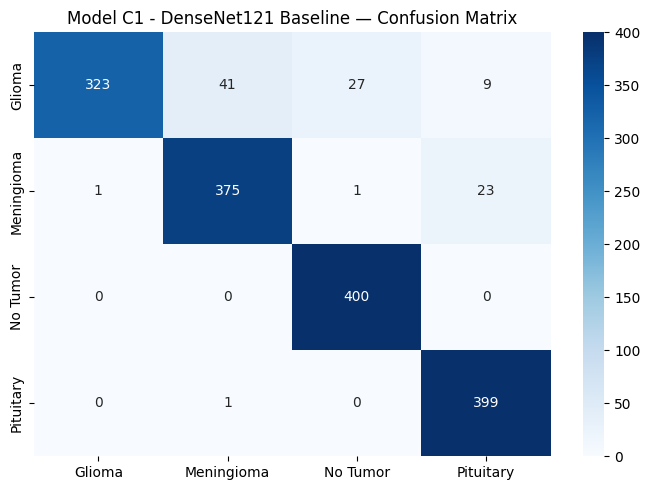

In [2]:
print("=== Model C1: DenseNet121 Baseline (No Attention) ===")
model_C1 = build_model(DenseNet121)
history_C1 = train_model(model_C1, 'model_C1')
acc_C1 = evaluate_model(model_C1, 'Model C1 - DenseNet121 Baseline')